# Meta-paths: two attention decisions in HAN

PROVIDED defines the complete mechanism. TODO cells are yours. Run CHECK immediately after each. EXIT requires your evidence and written defense. The full-run switch is off in the student copy; enable it only after the checks pass.

In [ ]:
# @colab-bootstrap — no hidden model imports; exact observed and portable versions are separate.
import sys,subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','numpy==2.2.6','scipy==1.15.3','torch==2.8.0','scikit-learn==1.7.2'])
import importlib.metadata as metadata
print({name:metadata.version(name) for name in ['numpy','scipy','torch','scikit-learn']})


## The skill you will leave with

**Define a typed route, turn it into a neighborhood, and explain both attention decisions in HAN.** Your deliverable is a trained ACM model with measured PAP/PSP weights and a defensible reproduction report. This connects the course mission—learning from relationships—to a precise choice: which relational routes should supply a prediction?

Take this in three sittings if needed: retrieval and the worked trace; implementation; then the full experiment and written defense. Reading the page is preparation. Mastery remains **PENDING_WRITTEN_DEFENSE**.



## 1 · Retrieve before reading

**Cold retrieval:** answer the three prompts before reading onward.

Without opening earlier lessons, write three answers: what does a GAT attention coefficient normalize over? Why does R-GCN assign different matrices to different edge roles? What makes a graph experiment transductive? Then check [L084 GAT](https://avistian.github.io/relational/lessons/0084-gat.html), [L091 R-GCN](https://avistian.github.io/relational/lessons/0091-r-gcn.html), and [L090 checkpoint](https://avistian.github.io/relational/lessons/0090-gnn-checkpoint.html).

**Bridge from L091.** R-GCN learns how each edge type changes a message. Two layers can compose those messages through an intermediate node. But that computation also mixes the intermediate node's other incoming information. Today's choice is different: specify a complete typed route first, connect its endpoints, then attend over the resulting neighbors. This does not make HAN universally better. It makes the route itself an explicit modeling assumption.

Primary reading: [Wang et al., HAN, §§3–4 and Figure 2](https://arxiv.org/html/1903.07293v2#S4). Read the mechanism first, then §§5.3–5.4 and Table 3 when auditing the lab. The [authors' release](https://github.com/Jhy1993/HAN/tree/71bac29a07fb8fab908d50a806a7bc38aa6c6611) is a second primary source; it does not agree with every paper equation.



## 2 · A meta-path is a template, not one walk

> **In plain terms.** “Papers that share an author” and “papers that share a subject” are two ways to define a paper's neighbors. The endpoint type is identical; the meaning is different.

A **heterogeneous graph** contains multiple node or edge types. A **meta-path** specifies a sequence of those types and relations. Here P means paper, A author, and S subject. **PAP** follows paper→author→paper. **PSP** follows paper→subject→paper. A **path instance** is one concrete sequence, such as paper p0→author a1→paper p2. A meta-path-based neighbor is a reachable endpoint. HAN's endpoint graph does not retain each intermediate author as a separate message.

**Worked example.** Let p0 have authors a0 and a1, p1 have a0 and a1, and p2 have a1 only. There are two PAP walks from p0 to p1, but p1 is one distinct neighbor. All three papers share a1, so the PAP endpoint graph connects every pair in this tiny example. Self is reachable too: p0→a0→p0.

Write the paper-author incidence matrix B with paper rows and author columns:

```text
       a0 a1
p0      1  1
p1      1  1
p2      0  1

B Bᵀ = [[2,2,1],       A_PAP = 1[B Bᵀ > 0] = [[1,1,1],
        [2,2,1],                              [1,1,1],
        [1,1,1]]                              [1,1,1]]
```

Matrix multiplication counts matching intermediates. Thresholding makes the result a reachability relation. Keeping counts would introduce a different message weighting. In database terms, this resembles a self-join through author IDs followed by `DISTINCT` on endpoint pairs. The shared-author route is specified by you; HAN learns weights within and between the routes you supply.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">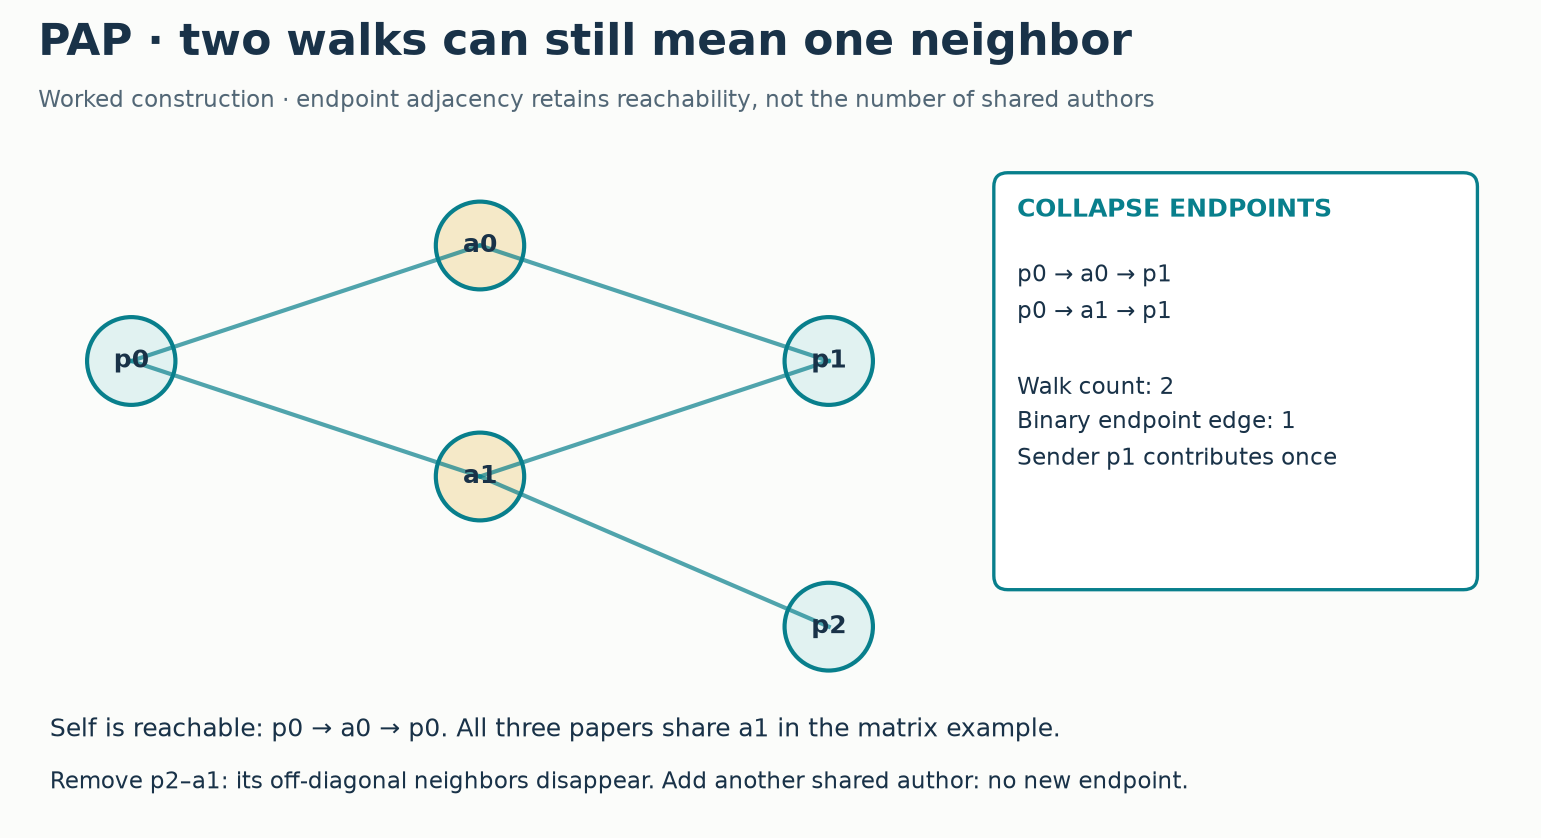</div><figcaption>Two shared-author walks collapse into one PAP endpoint edge; multiplicity is discarded.</figcaption></figure>

**CHECK before proceeding.** If p0 and p1 acquire a third shared author, does their binary PAP edge change? No. If p2 loses a1, does its neighborhood change? Yes. These interventions distinguish multiplicity from reachability. The lab makes you implement this distinction.

> **Scope check.** ACM's distributed artifact already contains PAP and a matrix named PLP. The authors' README says PLP represents PSP. The lab audits these endpoint matrices and practices typed multiplication separately; it cannot recover the discarded author/subject incidences from an endpoint adjacency matrix.



## 3 · First attention: which neighbor within this route?

> **In plain terms.** First choose the route. Then ask how much each reachable paper should contribute to this paper's representation.

A **feature vector** xᵢ lists the input measurements for node i. For ACM these are keyword indicators. A head projects that vector into eight learned coordinates, hᵢ = W xᵢ. A **head** is one independently parameterized attention calculation. Different heads can learn different notions of usefulness.

For receiver i and sender j, compute a score eᵢⱼ = LeakyReLU(a_leftᵀhᵢ + a_rightᵀhⱼ + c_left + c_right). LeakyReLU leaves positive values unchanged and multiplies negative values by 0.2. The affine offsets c are present in the released implementation. Only j in the chosen route's neighborhood is eligible.

Normalize with a **softmax**: exponentiate scores and divide by their sum over eligible senders. Thus αᵢⱼ = exp(eᵢⱼ)/Σₖexp(eᵢₖ). Before dropout, each receiver's coefficients sum to one. The head returns ELU(Σⱼαᵢⱼhⱼ + bias). ELU leaves positive inputs unchanged and maps a negative input t to exp(t)−1. This is the GAT operation from L084, applied to one meta-path graph.

**Worked example.** Suppose p0's three eligible messages have scalar values [1,3,5] and pre-softmax scores [0,ln 2,0]. The exponentials are [1,2,1], so α=[0.25,0.50,0.25]. The weighted message is 0.25×1 + 0.50×3 + 0.25×5 = 3. Increase the last score to ln 4: α=[1/7,2/7,4/7], and the message becomes 27/7≈3.857. Features and reachability stayed fixed; only the neighbor score changed.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">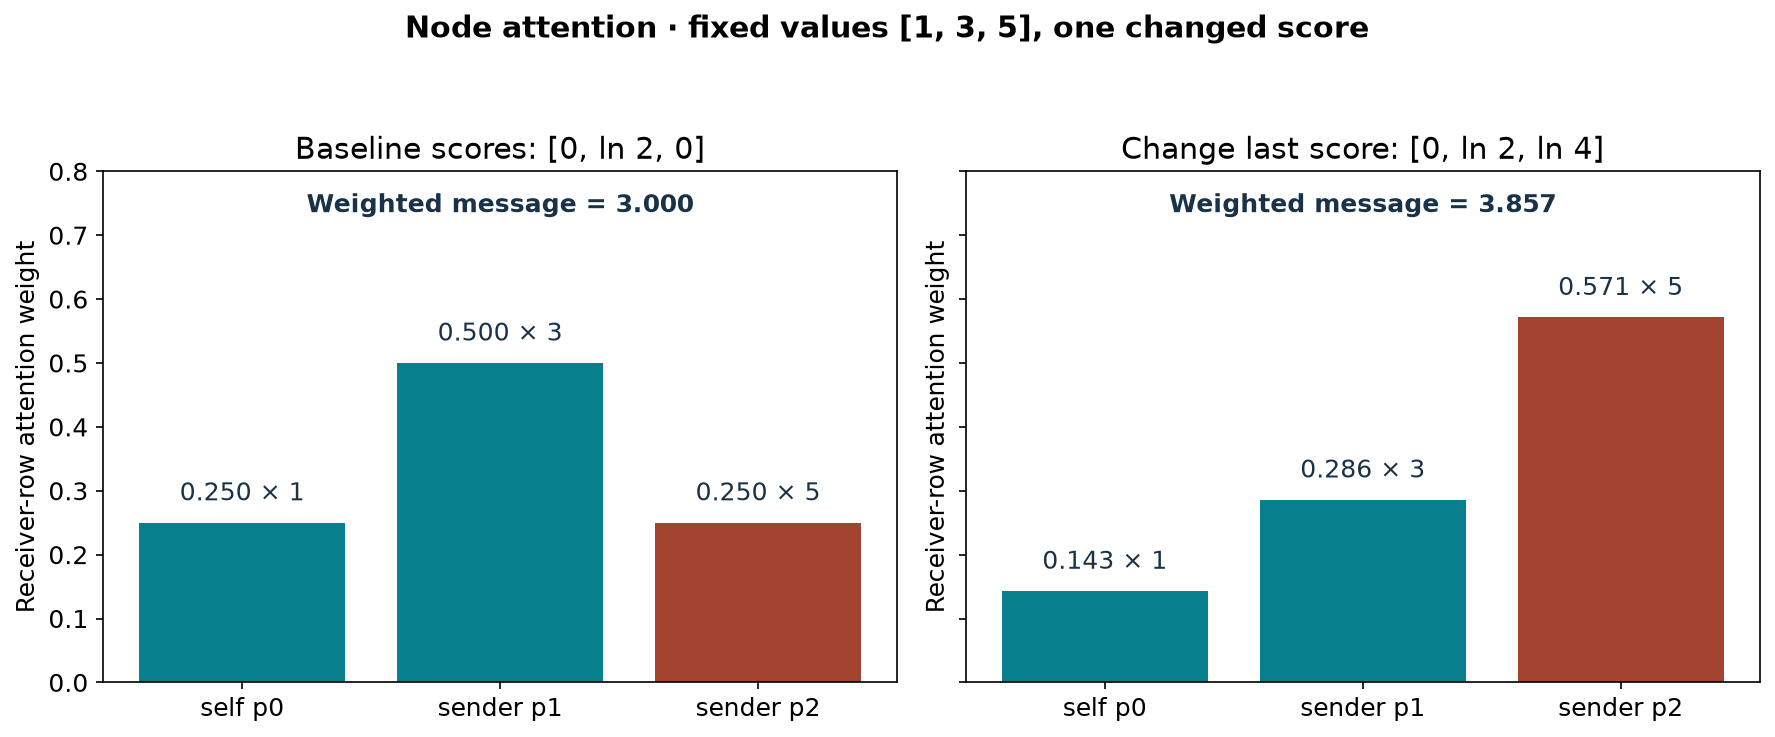</div><figcaption>Receiver attention changes from [.25,.50,.25] to [1/7,2/7,4/7]; fixed sender values yield 3 then 3.857.</figcaption></figure>

The runnable implementation uses sorted `(receiver, sender)` indices, a numerically stable per-receiver softmax, then sparse matrix multiplication. A separate dense masked-softmax oracle checks its outputs **and gradients**. An empty row would return zero, but the ACM loader includes one self edge for every paper.

**Release detail.** Dropout randomly zeros values and rescales survivors during training. The released head applies dropout at three sites: input features, attention coefficients, and projected values. The rate is 0.6; inference disables all three. Individual dropped coefficient rows need not sum to one. Each path/head has its own parameters, shared across that head's node/edge computations.



## 4 · Model architecture: preserve the two meanings until fusion

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">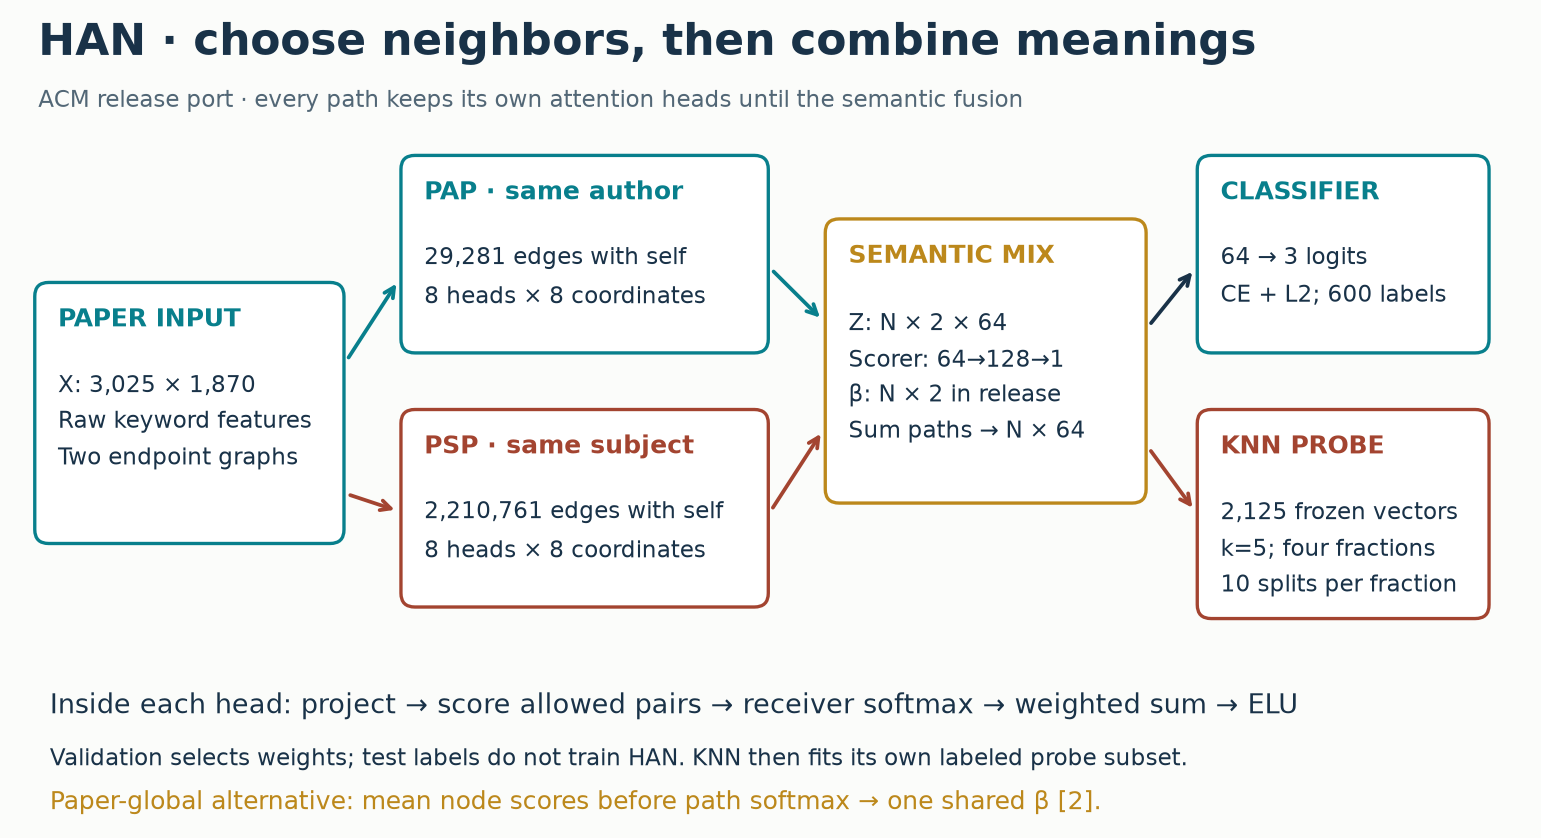</div><figcaption>Full ACM HAN release port: two eight-head branches, semantic fusion, masked training and a separate KNN evaluation.</figcaption></figure>

Follow p0 through the diagram. Its same-author and same-subject neighborhoods are different supports. Eight heads on PAP concatenate into zᵖᴬᴾ₀ with 64 coordinates. Eight other heads on PSP produce zᵖˢᴾ₀. **Concatenation** places head outputs next to each other; it does not average them. The stacked tensor Z has shape [3,025 nodes, 2 paths, 64 coordinates].

The semantic scorer has parameters Wₛ [64,128], bₛ [128], and q [128]. For each node/path vector it computes sᵢᵖ = qᵀ tanh(zᵢᵖ Wₛ + bₛ). The scorer parameters are shared across paths and nodes, so its two scores are comparable within the learned representation. A weighted sum across the two path embeddings returns one 64-vector per paper. A linear 64→3 classifier produces three **logits**, unnormalized class scores.

The training objective is cross-entropy on the 600 training labels plus the released L2 penalty. Cross-entropy penalizes low predicted probability for the correct class. Validation labels choose the checkpoint; they do not enter gradient updates. The complete graph and all keyword features are visible during training, so this is **transductive** learning. That is the declared protocol, not an inductive test on unseen graphs.

Two inference handoffs must remain distinct: classifier argmax gives direct test accuracy; the frozen 64-dimensional embeddings feed the Table 3 KNN evaluation. The KNN stage fits a separate classifier and uses additional labeled probe examples. Its F1 score is not the neural head's accuracy.



## 5 · Second attention: which route—and whose weights?

> **In plain terms.** Once each route has produced a representation, combine those representations. The paper and original code disagree about whether that route mixture must be identical for every node.

**Paper equation (7).** Average the semantic scores over nodes first: wᵖ = (1/N)Σᵢsᵢᵖ. **Equation (8)** applies softmax across paths, yielding βᵖ. **Equation (9)** computes zᵢ = Σₚβᵖ zᵢᵖ. Every node shares the same β, although each node's embeddings differ. A remote feature change can therefore affect another node's mixture through that average.

**Released `SimpleAttLayer`.** The [pinned code](https://github.com/Jhy1993/HAN/blob/71bac29a07fb8fab908d50a806a7bc38aa6c6611/utils/layers.py) applies softmax directly to each node's path scores. It computes βᵢᵖ, without averaging over nodes. The mean of these per-node weights is a useful descriptive summary, but it is not the globally shared coefficient from equation (8).

**Predict before computing:** can another node change your mixture under each semantic rule?

**Worked example.** Two nodes have path scores [[2,0],[0,0]]. Paper-global averaging gives [1,0] and shared weights [0.731,0.269]. Released per-node softmax gives [0.881,0.119] for the first node and [0.5,0.5] for the second. Averaging these weights yields [0.690,0.310]. **Softmax of the mean and mean of softmax are different operations.**

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">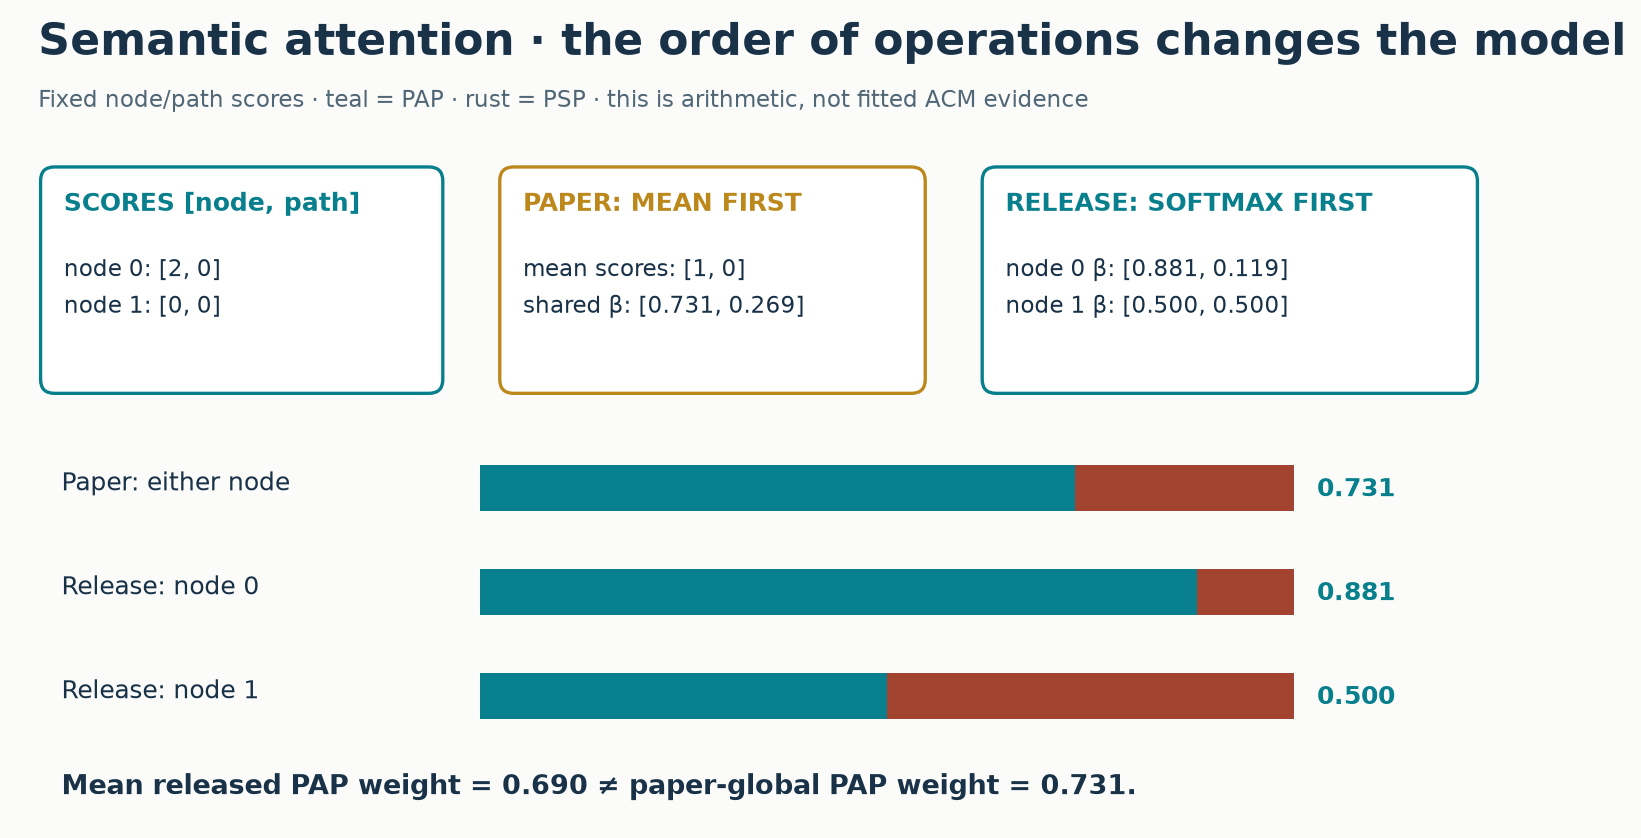</div><figcaption>Softmax of mean scores differs from mean per-node softmax: 0.731 versus 0.690 PAP weight.</figcaption></figure>

**Intervene on the arithmetic:** replace node 1’s PAP score 0 with 4. Global node 0 weight becomes softmax([3,0]) ≈ .953; released node 0 weight stays .881.

The lab supports explicit modes `paper_global` and `release_node`; no silent toggle hides this distinction. Task C implements both, and the actual model calls that live function. The full reproduction lane follows `release_node` because its contract is the released training program. A small paired intervention shows the effect of changing this mode on the same weights; it is not a trained ablation or evidence that one variant wins.

**Interpretation boundary.** If PAP has the highest average weight, report that fact for this model, split, and seed. It does not establish that shared authors cause a paper's research area. Correlated routes can substitute for each other, embeddings have learned scales, and high weight alone is not a performance ablation. To test predictive reliance, remove a path, refit under the same selection protocol, and compare held-out scores across declared seeds.



## 6 · Reproduce the named experiment, not a familiar-looking score

The target is **HAN Table 3, ACM, all four KNN training fractions**. A 20% fraction here refers to the downstream probe subset, not “train HAN on 20% of all graph nodes.” The released main program trains on its fixed 600 labels, restores a checkpoint, extracts embeddings for the 2,125 test IDs, and passes those embeddings to `my_KNN`. That routine shuffles the available embeddings, fits 5-nearest-neighbor classification on the first fraction, and scores the remainder. A **nearest-neighbor classifier** predicts a class from the five closest stored feature vectors, using Euclidean distance and a majority vote here.

**Micro-F1** pools class counts before computing F1; for single-label multiclass prediction it equals accuracy. **Macro-F1** averages each class's F1 equally. Both are preserved, along with every probe split and prediction. Ten repeated probe splits reuse the same nodes and frozen embedding; they are not ten independent graph datasets or ten independent encoder fits.

| Protocol item | Executable lesson contract |
|---|---|
| Source | Jhy1993/HAN revision `71bac29a07fb8fab908d50a806a7bc38aa6c6611` |
| Data | Hash-verified DGL ACM3025 mirror; raw 1,870-dimensional features; binary PAP/PSP including self |
| Split | Released 600 train / 300 validation / 2,125 test IDs |
| Model | 2 paths × 8 heads × 8 coordinates; semantic width 128; three-class linear head |
| Optimizer | Adam 0.005; 0.001×½Σθ² over all parameters; dropout 0.6 |
| Schedule | 200-epoch ceiling; patience 100; release OR-reset / AND-save checkpoint rule |
| Evaluation | Frozen test embeddings; KNN k=5; fractions 0.2/0.4/0.6/0.8; ten cumulative shuffles per fraction |
| Randomness | Declared encoder seed and separate probe seed; historical RNG states unavailable |
| Acceptance | Descriptive ±2 percentage-point tolerance fixed before execution; protocol verdict remains separate |

**Why checkpoint detail matters.** The release resets patience when validation accuracy improves **or** validation loss improves. It saves weights only when both conditions hold at the same epoch, with equality allowed. That differs from selecting minimum validation loss alone. The code records the selected epoch and the entire validation trace; test labels never select an epoch.

**Why regularization detail matters.** The source excludes a list of short variable names, but TensorFlow variable names carry scopes and suffixes. The port explicitly regularizes all learned parameters, including biases. It uses Glorot-uniform projection/readout initialization and normal semantic parameters with standard deviation 0.1, following the released initializers. PyTorch's optimizer/random-number implementation still differs from TensorFlow 1.

**Author-reference evidence; not your current kernel output.** 1 complete encoder fit; 200 epochs executed; validation selected epoch 35. Direct test-head accuracy 87.44%.

| KNN training fraction | Measured macro-F1 ± split SD | Paper macro | Measured micro-F1 ± split SD | Paper micro |
|---|---:|---:|---:|---:|
| 20% | 87.88 ± 1.00% | 89.40% | 87.72 ± 1.07% | 89.22% |
| 40% | 88.04 ± 0.77% | 89.79% | 87.84 ± 0.81% | 89.64% |
| 60% | 88.53 ± 1.35% | 89.51% | 88.32 ± 1.44% | 89.33% |
| 80% | 88.18 ± 1.65% | 90.63% | 87.98 ± 1.68% | 90.54% |

Mean released semantic weights over all nodes: **PAP 0.7095, PSP 0.2905**. The higher-weight path is **PAP**. These are averaged node-specific weights, not the paper-global coefficient.

Frozen ±2pp descriptive tolerance: 20%: both within; 40%: both within; 60%: both within; 80%: at least one outside. This does not change the INCOMPARABLE protocol verdict.

Each SD is over ten dependent probe splits of one fixed embedding. There is no encoder-seed uncertainty estimate. The full run retains predictions and validation traces. Numerical proximity does not remove the protocol differences.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">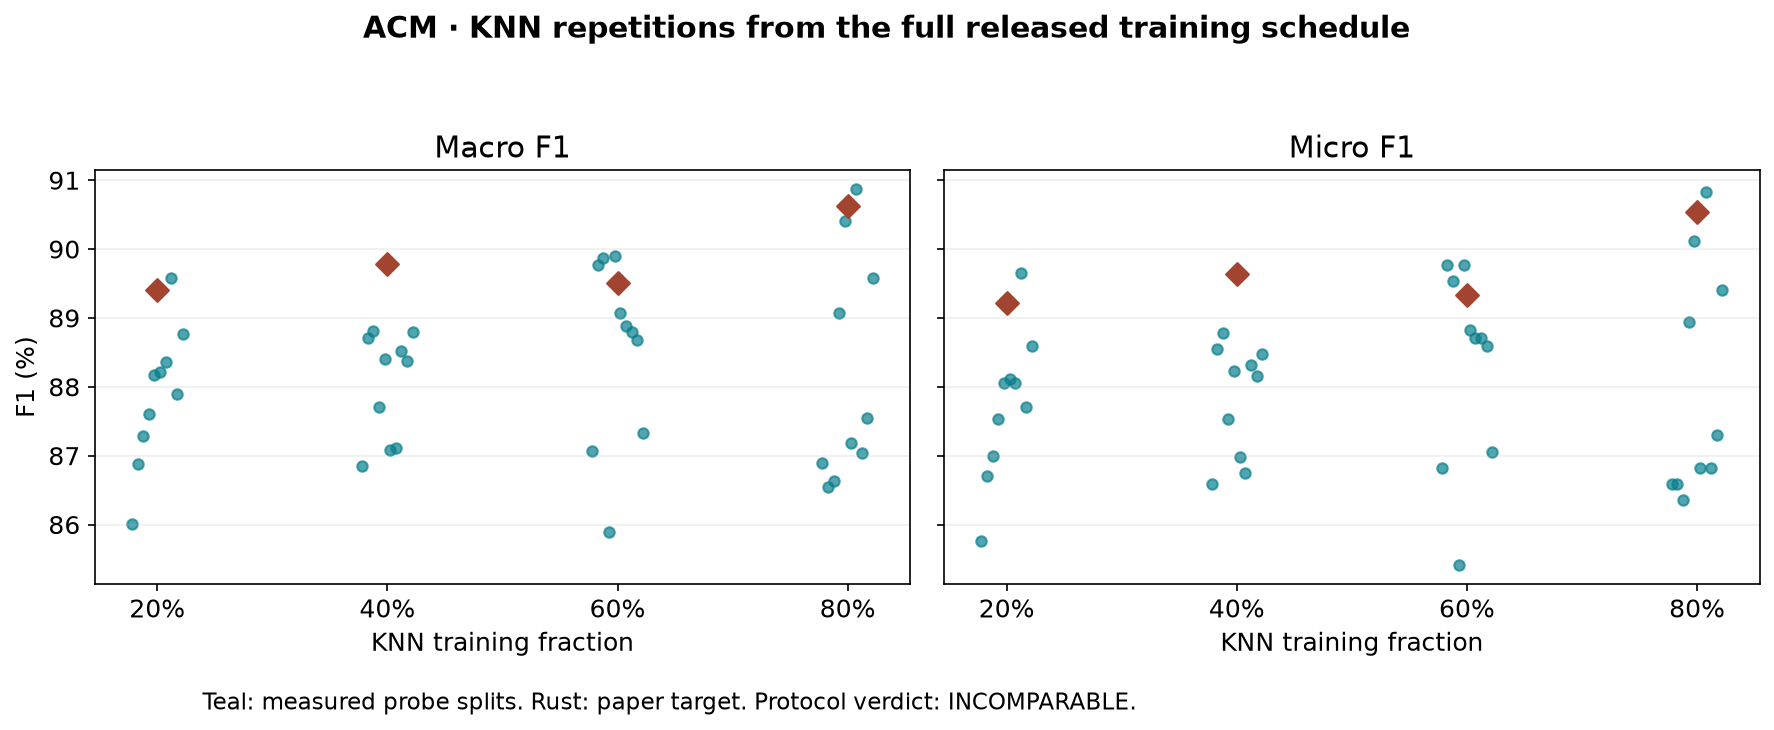</div><figcaption>Full-run KNN split scores versus Table3 targets. Probe variability is conditional on one embedding; historical protocol is incomparable.</figcaption></figure>

> **Scope check.** This is a full-size released-protocol reconstruction, not established full-paper reproduction. The original MAT file's byte identity with the DGL mirror is unverified. The release's semantic reduction and stopping rule differ from the paper. The historical seeds, exact paper checkpoint, and table-to-release mapping are unavailable. DBLP, IMDB, all baselines, clustering, and paper-wide ablations remain **NOT_RUN**. Historical parity is **INCOMPARABLE** and full-paper parity **NOT_ESTABLISHED**, even if numerical scores are close.

**Independent replay.** The complete inline notebook implementation also ran all 200 epochs and forty probes from a fresh directory. Predictions, checkpoint choice and KNN results matched exactly; the largest validation-loss difference was 0.0000066. Bitwise loss equality failed. [Replay audit](https://avistian.github.io/relational/labs/_replay_l092_results.json) records that difference. The downloadable solution has separately regenerated diagnostic outputs with the full switch off; its saved outputs do not pretend to contain the earlier full run.

[Protocol/deviation ledger](https://avistian.github.io/relational/labs/l092-reproduction.md) · [Source and data hashes](https://avistian.github.io/relational/labs/_sources_l092.json) · [Raw results](https://avistian.github.io/relational/labs/_paper_l092_results.json) · [Behavior checks](https://avistian.github.io/relational/labs/_verify_l092_results.json)



## 7 · Lab: make the trained computation depend on your code

Open the [student notebook](https://avistian.github.io/relational/labs/0092-meta-paths.ipynb) or [prepared HTML](https://avistian.github.io/relational/labs/html/0092-meta-paths.html). The notebook includes this explanation and portable figures. All model, loader, trainer, and evaluation code is visible.

1. **TODO A — reachability.** Compose typed incidence matrices and collapse positive walk counts to distinct endpoints. CHECK distinguishes duplicate walks from new neighbors.
2. **TODO B — node attention.** Normalize scores within receiver rows and aggregate the correct sender values. CHECK compares exact arithmetic and gradients against an independent dense implementation.
3. **TODO C — semantic fusion.** Implement both reduction orders. CHECK exposes the difference and verifies that parameters receive gradients.
4. **RUN — smoke, then full.** The small diagnostic establishes wiring. Enable the separate full-run switch for the 200-epoch target and all forty KNN evaluations. A disabled switch prints `NOT_RUN`.
5. **EXIT — defend the claim.** Submit the JSON plus a 150–250 word explanation of reachability, both softmax axes, which path received greater weight, and the remaining reproduction gaps.

Command from the course root:

```bash
.venv/bin/python labs/_verify_l092.py
.venv/bin/python labs/_run_l092.py --seeds 0 --output labs/_paper_l092_results.json
```

The CPU run uses the full graph and model. Runtime and exact environment are recorded in the artifacts. Repeating the command retrains; it does not quietly load an earlier score. Extra `--seeds 0 1 2` runs measure initialization variability; the primary one-fit result has no encoder-seed error bar.



## 8 · Defend, then connect forward

**Teach-back:** write your explanation before comparing it with the equations above.

**Exit challenge.** Explain why averaging two R-GCN layers is not generally the same computation as constructing PAP then applying one GAT layer. Name what the intermediate node can mix and what the endpoint projection discards. Then explain why a learned route weight does not by itself justify choosing that route for a production database.

**Next: L093 HGT.** HAN starts from a hand-specified set of multi-hop routes. HGT instead makes attention depend on source type, edge type, and target type. Later, [L141 in the curriculum](https://avistian.github.io/relational/reference/curriculum.html) revisits direct routes through relational databases. Before then, preserve the distinction between the schema template, its instances, the endpoint graph, and the learned weight.

Return tomorrow and derive both attention axes without notes. In a week, implement the three tasks again from the contracts. Ask the teacher follow-up questions or paste your written defense for a strict review; an executed notebook alone does not pass the lesson.


## PROVIDED · Provenance and runtime
The digest is checked before loading the public pickle. No normalization or split regeneration is applied. This is an independently written modern port of the pinned release; it is not the original TensorFlow runtime.

In [ ]:
SOURCE_MANIFEST={'paper': 'https://arxiv.org/abs/1903.07293v2', 'source_url': 'https://github.com/Jhy1993/HAN', 'source_revision': '71bac29a07fb8fab908d50a806a7bc38aa6c6611', 'files': {'ex_acm3025.py': '58fa9a40e76baac4276328ca9a5800b8e2a1bf6cfeb0bb94bbc0a10fdaa5b822', 'base_gattn.py': 'cb4b35fb8ce69e9e20a28587a38df92a47eaa6a4264c26c7fcb86aa885e7a4ad', 'gat.py': '1465f23e5c993e99c0ad3721b7af17ebd3da3aa8e9f035ce7a5589b7334b652e', 'README.md': 'e0861a2cd0808d0d0793baa02c7b3dd25bff243f70a2fc6665cd5303913ff8ed', 'jhyexp.py': '64e239e477d95ac870d8878c54d0b2a26aa82231428c251671e51826110c8734', 'dgl_utils.py': '89280e3735f56fbf0ec074a014cc940e8eb92f78de8cd7ad2247edb0e511b5fa', 'layers.py': '4d89dc2b41f7efac3409122fe695e2d573bcfbb5b885b265d5c3fedda6c3ce1a'}, 'data': {'url': 'https://data.dgl.ai/dataset/ACM3025.pkl', 'sha256': 'b21cb3cb3c5b1f8562493942ddbc65c900a01fb58338adaf17966e4c8959161b'}, 'environment': {'python': '3.12.3', 'machine': 'aarch64', 'numpy': '2.5.0', 'scipy': '1.18.0', 'torch': '2.13.0+cpu', 'scikit-learn': '1.9.0'}}

In [ ]:
"""Visible PyTorch reconstruction of Jhy1993/HAN; see l092-reproduction.md.
Written for teaching from the pinned release equations and training recipe.
Paper-global and released per-node semantic attention are explicit alternatives.
"""

In [ ]:
import copy

In [ ]:
import hashlib

In [ ]:
import json

In [ ]:
import pickle

In [ ]:
import time

In [ ]:
import urllib.request

In [ ]:
from pathlib import Path

In [ ]:
import numpy as np

In [ ]:
import scipy.sparse as sp

In [ ]:
import torch

In [ ]:
from torch import nn

In [ ]:
from torch.nn import functional as F

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from sklearn.metrics import f1_score

### TODO · Compose typed relations
**Goal:** Multiply compatible incidence matrices, then return binary endpoint reachability. Preserve self when reachable; discard counts.
**Why:** this function sits on the actual training path. Use the dimensions and worked example above; CHECK validates behavior.

In [ ]:
def metapath_reachability(relations):
    raise NotImplementedError("Complete this task before CHECK")

In [ ]:
# CHECK
b=sp.csr_matrix([[1,1],[1,1],[0,1]],dtype=np.float32)
a=metapath_reachability([b,b.T]);assert a.nnz==9 and a[0,1]==1
c=sp.csr_matrix([[1,1],[1,1],[0,0]],dtype=np.float32)
assert metapath_reachability([c,c.T]).nnz==4
print('CHECK: duplicate walks collapse; changed endpoint membership changes reachability')

### TODO · Attend within a route
**Goal:** Compute stable receiver-row softmax, coefficient dropout, then weighted sender aggregation. Edges are sorted unique receiver/sender pairs; h already contains projected-value dropout.
**Why:** this function sits on the actual training path. Use the dimensions and worked example above; CHECK validates behavior.

In [ ]:
def neighbor_attention(h,edge,left,right,dropout,training):
    raise NotImplementedError("Complete this task before CHECK")

In [ ]:
# CHECK
h=torch.tensor([[1.],[3.],[5.]],requires_grad=True)
e=torch.tensor([[0,0,0,1,2],[0,1,2,1,2]])
l=torch.zeros(3);r=torch.tensor([0.,np.log(2),0.],dtype=torch.float32,requires_grad=True)
o=neighbor_attention(h,e,l,r,0.,False)
torch.testing.assert_close(o,torch.tensor([[3.],[3.],[5.]]))
o.sum().backward();assert r.grad.abs().sum()>0
print('CHECK: receiver normalization, sender indexing, gradient flow')

### TODO · Combine route representations
**Goal:** Compute shared semantic scores, implement paper_global and release_node reduction orders, then return the fused embedding and node-by-path weights.
**Why:** this function sits on the actual training path. Use the dimensions and worked example above; CHECK validates behavior.

In [ ]:
def semantic_fusion(z,w,b,q,mode):
    raise NotImplementedError("Complete this task before CHECK")

In [ ]:
# CHECK
z=torch.tensor([[[2.,0.],[0.,0.]],[[0.,0.],[0.,0.]]],requires_grad=True)
w=torch.eye(2,requires_grad=True);b=torch.zeros(2);q=torch.tensor([1.,0.],requires_grad=True)
scores=torch.tanh(z)@q
g,bg=semantic_fusion(z,w,b,q,'paper_global');n,bn=semantic_fusion(z,w,b,q,'release_node')
torch.testing.assert_close(bg,scores.mean(0).softmax(0).expand(2,-1))
torch.testing.assert_close(bn,scores.softmax(1));assert not torch.allclose(bg,bn)
g.sum().backward();assert q.grad.abs().sum()>0 and w.grad.abs().sum()>0
print('CHECK: both semantic reduction orders and learned gradients')

### PROVIDED · masked loss
Paper Eq10 and release BaseGAttN.masked_softmax_cross_entropy. Only these training indices supervise the encoder.

In [ ]:
def masked_loss(logits,labels,indices):
    return F.cross_entropy(logits[indices],labels[indices])

### PROVIDED · AttentionHead
Paper §4.1, Eqs1–5; release utils/layers.py attn_head. Follow all three dropout sites and the per-receiver normalization.

In [ ]:
class AttentionHead(nn.Module):
    """Release head: three dropout sites, affine attention scores, post-sum bias, ELU."""
    def __init__(self,features,width=8,dropout=.6):
        super().__init__();self.dropout=dropout
        self.projection=nn.Linear(features,width,bias=False)
        self.left=nn.Linear(width,1);self.right=nn.Linear(width,1)
        self.bias=nn.Parameter(torch.zeros(width))
        for layer in [self.projection,self.left,self.right]:
            nn.init.xavier_uniform_(layer.weight)
            if layer.bias is not None:nn.init.zeros_(layer.bias)
    def forward(self,x,edge):
        h=self.projection(F.dropout(x,self.dropout,self.training))
        left=self.left(h).squeeze(-1);right=self.right(h).squeeze(-1)
        values=F.dropout(h,self.dropout,self.training)
        return F.elu(neighbor_attention(values,edge,left,right,self.dropout,self.training)+self.bias)

### PROVIDED · HAN
Paper Figure2 and §4.2; release models/gat.py HeteGAT_multi. Keep separate path/head parameters and inspect the classifier handoff.

In [ ]:
class HAN(nn.Module):
    """Two path-specific banks of eight heads; 64→128 semantic scorer; 64→3 readout."""
    def __init__(self,features,classes=3,mode='release_node',paths=2):
        super().__init__();self.mode=mode
        self.branches=nn.ModuleList([nn.ModuleList([AttentionHead(features) for _ in range(8)]) for _ in range(paths)])
        self.w=nn.Parameter(torch.randn(64,128)*.1)
        self.b=nn.Parameter(torch.randn(128)*.1)
        self.q=nn.Parameter(torch.randn(128)*.1)
        self.readout=nn.Linear(64,classes)
        nn.init.xavier_uniform_(self.readout.weight);nn.init.zeros_(self.readout.bias)
    def forward(self,x,edges):
        if len(edges)!=len(self.branches):raise ValueError('One support required per branch')
        z=torch.stack([torch.cat([head(x,edge) for head in branch],dim=1) for branch,edge in zip(self.branches,edges)],dim=1)
        embedding,beta=semantic_fusion(z,self.w,self.b,self.q,self.mode)
        return self.readout(embedding),embedding,beta

### PROVIDED · load acm
Release ex_acm3025.py load_data_dblp plus the DGL mirror loader. Hashes and original split IDs determine this experiment.

In [ ]:
def load_acm(root,manifest):
    root=Path(root);root.mkdir(parents=True,exist_ok=True);path=root/'ACM3025.pkl'
    spec=manifest['data']
    if not path.exists():
        with urllib.request.urlopen(spec['url'],timeout=120) as response:path.write_bytes(response.read())
    digest=hashlib.sha256(path.read_bytes()).hexdigest()
    if digest!=spec['sha256']:raise ValueError('Dataset checksum mismatch; refusing deserialization')
    # Only deserialize bytes from the fixed, verified DGL dataset digest.
    with path.open('rb') as f:data=pickle.load(f)
    x=torch.tensor(data['feature'].toarray(),dtype=torch.float32)
    y=torch.tensor(np.asarray(data['label'].toarray()).argmax(1),dtype=torch.long)
    edges=[];counts=[]
    for key in ['PAP','PLP']:
        support=metapath_reachability([data[key]])
        support.setdiag(1);support.eliminate_zeros();support.sort_indices()
        a=support.tocoo();edge=torch.tensor(np.stack([a.row,a.col]),dtype=torch.long)
        edges.append(edge);counts.append(support.nnz)
    indices=[torch.tensor(data[key].ravel(),dtype=torch.long) for key in ['train_idx','val_idx','test_idx']]
    train,val,test=indices
    assert x.shape==(3025,1870) and len(torch.unique(torch.cat(indices)))==3025
    assert [len(v) for v in indices]==[600,300,2125]
    meta={'sha256':digest,'nodes':len(x),'features':x.shape[1],'edges_PAP_PSP':counts,'split':[len(v) for v in indices],
          'split_sha256':hashlib.sha256(b''.join(v.numpy().tobytes() for v in indices)).hexdigest(),
          'provenance':'DGL ACM3025 mirror; original authors MAT byte identity not established'}
    return x,y,edges,train,val,test,meta

### PROVIDED · knn probe
Paper §5.4/Table3 and release jhyexp.py my_KNN. The probe fits its own labels on frozen test-node embeddings.

In [ ]:
def knn_probe(embedding,labels,node_ids,seed=1000):
    """Release jhyexp.py: cumulative shuffle; first floor(n*f) train, remaining test, k=5."""
    rng=np.random.RandomState(seed);x=np.asarray(embedding);y=np.asarray(labels);ids=np.asarray(node_ids)
    records=[]
    for fraction in [.2,.4,.6,.8]:
        for repeat in range(10):
            permutation=rng.permutation(len(x));x=x[permutation];y=y[permutation];ids=ids[permutation]
            cut=int(len(x)*fraction)
            model=KNeighborsClassifier(n_neighbors=5);model.fit(x[:cut],y[:cut]);prediction=model.predict(x[cut:])
            records.append({'fraction':fraction,'repeat':repeat,'macro_f1':float(f1_score(y[cut:],prediction,average='macro')),
                'micro_f1':float(f1_score(y[cut:],prediction,average='micro')),'train_ids':ids[:cut].tolist(),
                'test_ids':ids[cut:].tolist(),'predictions':prediction.tolist()})
    return records

### PROVIDED · train acm
Paper §5.3 versus release ex_acm3025.py training loop. Trace L2 scope and the OR-reset / AND-save selection rule.

In [ ]:
def train_acm(data,seed=0,epochs=200,mode='release_node',progress=False):
    torch.manual_seed(seed);np.random.seed(seed)
    x,y,edges,train,val,test,meta=data
    model=HAN(x.shape[1],mode=mode)
    # Upstream exact-name exclusion does not match scoped TF variable names: all parameters receive L2.
    optimizer=torch.optim.Adam(model.parameters(),lr=.005,eps=1e-8)
    best_acc=0.;best_loss=float('inf');waiting=0;checkpoint=None;selected_epoch=None;trace=[]
    started=time.perf_counter()
    for epoch in range(epochs):
        model.train();optimizer.zero_grad();logits,_,_=model(x,edges)
        loss=masked_loss(logits,y,train)
        regularizer=.001*.5*sum(p.square().sum() for p in model.parameters())
        (loss+regularizer).backward();optimizer.step()
        model.eval()
        with torch.no_grad():
            logits,_,_=model(x,edges);vl=float(masked_loss(logits,y,val));va=float((logits[val].argmax(1)==y[val]).float().mean())
        trace.append({'epoch':epoch+1,'train_ce':float(loss.detach()),'validation_ce':vl,'validation_accuracy':va})
        # Preserve upstream OR-reset / AND-save; equality counts as improvement.
        if va>=best_acc or vl<=best_loss:
            if va>=best_acc and vl<=best_loss:
                checkpoint=copy.deepcopy(model.state_dict());selected_epoch=epoch+1
            best_acc=max(best_acc,va);best_loss=min(best_loss,vl);waiting=0
        else:
            waiting+=1
            if waiting==100:break
        if progress and (epoch==0 or (epoch+1)%20==0):print(seed,mode,epoch+1,round(vl,4),round(va,4),round(time.perf_counter()-started,1),flush=True)
    assert checkpoint is not None
    model.load_state_dict(checkpoint);model.eval()
    with torch.no_grad():
        logits,z,beta=model(x,edges);prediction=logits[test].argmax(1)
    result={'seed':seed,'mode':mode,'epochs_completed':len(trace),'epoch_ceiling':epochs,'selected_epoch':selected_epoch,
       'early_stop_patience':100,'trace':trace,'test_accuracy':float((prediction==y[test]).float().mean()),
       'test_predictions':prediction.tolist(),'test_ids':test.tolist(),'test_labels':y[test].tolist(),
       'semantic_mean_all_nodes':beta.mean(0).tolist(),'semantic_mean_test':beta[test].mean(0).tolist(),
       'semantic_per_test_node':beta[test].tolist(),'seconds':time.perf_counter()-started,
       'knn':knn_probe(z[test].numpy(),y[test].numpy(),test.numpy(),1000+seed)}
    return result,model

### PROVIDED · summarize
Paper Table3 ACM targets. Aggregate probe repetitions without pretending they are independent graph datasets.

In [ ]:
def summarize(runs,meta):
    targets={.2:(.8940,.8922),.4:(.8979,.8964),.6:(.8951,.8933),.8:(.9063,.9054)}
    rows=[]
    for fraction,(macro,micro) in targets.items():
        records=[r for run in runs for r in run['knn'] if r['fraction']==fraction]
        rows.append({'fraction':fraction,'macro_mean':float(np.mean([r['macro_f1'] for r in records])),
         'micro_mean':float(np.mean([r['micro_f1'] for r in records])),
         'macro_split_sd':float(np.std([r['macro_f1'] for r in records],ddof=1)),
         'micro_split_sd':float(np.std([r['micro_f1'] for r in records],ddof=1)),
         'paper_macro':macro,'paper_micro':micro,'descriptive_tolerance_pp':2,
         'verdict':'INCOMPARABLE','reason':'release semantics, mirrored data provenance, modern backend and unavailable historical seeds'})
    return {'status':'FULL_RELEASE_SCHEDULE_EXECUTED' if all(r['epoch_ceiling']==200 for r in runs) else 'DIAGNOSTIC',
       'data':meta,'training_runs':len(runs),'knn_per_training_run':40,'table3_acm':rows,'runs':runs,
       'full_paper_parity':'NOT_ESTABLISHED','historical_parity':'INCOMPARABLE','remaining_datasets':'DBLP and IMDB NOT_RUN'}

## CHECK · Real ACM diagnostic and paired semantic intervention
Two full-graph updates test wiring, not paper performance. Keep weights fixed, then change only semantic reduction. This is an inference intervention, not a trained ablation.

In [ ]:
torch.set_num_threads(2)
DATA_ROOT=Path.cwd()/'l092-data'
data=load_acm(DATA_ROOT,SOURCE_MANIFEST)
assert load_acm.__globals__['metapath_reachability'] is metapath_reachability
assert AttentionHead.forward.__globals__['neighbor_attention'] is neighbor_attention
assert HAN.forward.__globals__['semantic_fusion'] is semantic_fusion
smoke,model=train_acm(data,seed=99,epochs=2)
x,y,edges,train,val,test,meta=data
model.eval()
with torch.no_grad():
    original,z,beta=model(x,edges)
    model.mode='paper_global'
    changed,zg,bg=model(x,edges)
    assert not torch.allclose(original,changed)
    assert torch.allclose(bg[0],bg[-1])
print({'diagnostic_epochs':2,'max_logit_change_same_weights':float((changed-original).abs().max()),'data':meta})


## RUN · Full released schedule and Table3 ACM probe
Enable after the checks pass. One encoder fit, up to200 epochs with released early stopping, all40 probe evaluations. Seeds: encoder0, probe1000. The paper/code/mirror differences keep historical parity INCOMPARABLE. No saved-score substitution occurs.

In [ ]:
RUN_FULL_REPRO = False
paper_result=None
if RUN_FULL_REPRO:
    full_run,full_model=train_acm(data,seed=0,epochs=200,mode='release_node',progress=True)
    paper_result=summarize([full_run],data[-1])
    Path('l092-paper.json').write_text(json.dumps(paper_result,indent=2))
    print(paper_result['table3_acm'])
    print({'semantic_mean':full_run['semantic_mean_all_nodes'],'historical_parity':'INCOMPARABLE'})
else:
    print('Full reproduction lane: NOT_RUN in this kernel')


## EXIT · Evidence plus written defense
Write150–250 words in a new markdown cell. Derive both softmax axes, state which path receives greater mean weight, distinguish that average from paper-global attention, and explain why KNN repetitions are not independent model fits. Name at least three historical reproduction gaps. Ask the teacher to challenge your report.

In [ ]:
exit_ticket={'lesson':92,'full_release_execution':paper_result['status'] if paper_result else 'NOT_RUN',
 'historical_parity':'INCOMPARABLE','full_paper_parity':'NOT_ESTABLISHED','learner_mastery':'PENDING_WRITTEN_DEFENSE',
 'source_revision':SOURCE_MANIFEST['source_revision'],'data_sha256':SOURCE_MANIFEST['data']['sha256']}
Path('l092-exit.json').write_text(json.dumps(exit_ticket,indent=2));print(exit_ticket)
